# Cosimita: near and extended sources

Every source so far has been a *far-field* source at a single direction, or
uniform over the whole sky. This notebook adds the two remaining ways to place
a source, and they differ in opposite directions:

- **`NearPointSource`** is close enough that its *distance* matters. It sits at
  a fixed **detector-frame position** -- inside the instrument, or just beside
  it -- and is normalized by a **rate** in `1/s`, not a flux. This is the
  instrumental-background source: activation in the structure, a calibration
  source, a hot box on the bus.
- **`ExtendedSource`** is still at infinity, but is *smeared* over the sky
  rather than sitting at one angle. It is normalized by a flux like any other
  far-field source.

Still flatland: the Earth is a circle, the sky is a 1-D circle of directions,
fluxes are per unit *length* per second.

This notebook uses **COMPTELito**, the traditional tracker-on-top detector from
tutorial 01, for the same reason notebooks 00 and 02 do:
`SimpleTraditionalReconstructor` needs the first hit in layer 0 with a
calorimeter below it, which COSIta's uniform stack does not provide.

In [1]:
from gammaraytoys import ToyTracker2D
from gammaraytoys.coordinates import Cartesian2D
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

comptelito = ToyTracker2D(material = 'Ge',
                          layer_length = 10*u.m,
                          layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                          layer_thickness = 1*u.cm,
                          energy_resolution = 0.03,
                          energy_threshold = 20*u.keV)

centre = comptelito.surrounding_circle_center
radius = comptelito.surrounding_circle_radius

print(f"surrounding circle: centre = ({centre.x:.3f}, {centre.y:.3f}), radius a = {radius:.4f}")
print(f"throwing plane size 2a = {comptelito.throwing_plane_size:.4f}")

surrounding circle: centre = (0.000 m, 150.000 cm), radius a = 5.2202 m
throwing plane size 2a = 10.4403 m


Note the circle's centre is **not** the origin -- it sits at the middle of the
layer stack, 150 cm up. Everything below measures the source's distance `s`
from *that* point, not from `(0, 0)`.

## 1. `NearPointSource`: a rate, and a geometric acceptance

A near source emits isotropically over the full `2*pi`, at a total rate
`rate` [1/s]. Only the fraction aimed at the detector is worth simulating, so
`simulated_rate()` folds in a geometric **acceptance** `f`:

- **outside the circle** (`s >= a`): the circle subtends a half-angle
  `Delta = arcsin(a/s)`, so `f = Delta/pi` and the flight direction is drawn
  uniformly inside that wedge.
- **inside the circle** (`s < a`): every direction reaches the circle, so
  `f = 1` and the direction is uniform over the full `[0, 360) deg`.

There is no rejection step in either branch -- every direction drawn is one
that geometrically reaches the surrounding circle. Whether it then hits a
*layer* is a separate matter, and Section 3 shows exactly where that fails.

In [2]:
from gammaraytoys.sims import NearPointSource, MonoenergeticSpectrum

def near_source_at(distance_in_a, rate = 1000/u.s):
    """A NearPointSource `distance_in_a * a` to the right of the circle centre."""
    return NearPointSource(position = Cartesian2D(centre.x + distance_in_a*radius, centre.y),
                           spectrum = MonoenergeticSpectrum(1*u.MeV),
                           rate = rate)

print(f"{'s/a':>8}  {'f (simulated_rate/rate)':>24}  {'arcsin(a/s)/pi':>16}")
for ratio in [0.0, 0.5, 1.0, 1.5, 2.0, 5.0, 20.0]:
    src = near_source_at(ratio)
    f = (src.simulated_rate(comptelito) / (1000/u.s)).to_value(u.dimensionless_unscaled)
    exact = 1.0 if ratio < 1.0 else np.arcsin(1.0/ratio)/np.pi
    print(f"{ratio:8.2f}  {f:24.6f}  {exact:16.6f}")

     s/a   f (simulated_rate/rate)    arcsin(a/s)/pi
    0.00                  1.000000          1.000000
    0.50                  1.000000          1.000000
    1.00                  0.500000          0.500000
    1.50                  0.232280          0.232280
    2.00                  0.166667          0.166667
    5.00                  0.064094          0.064094
   20.00                  0.015922          0.015922


Two things to notice.

The acceptance **jumps discontinuously at `s = a`**, from `1.0` just inside to
`0.5` just outside. That is not a bug: a source sitting exactly on the circle
radiates half of its output inward and half outward, and `arcsin(a/s) -> pi/2`
gives `f -> 1/2` from the outside. The inside branch is the limit of a source
that cannot miss.

And the acceptance falls off like `a/s` once the source is far away -- at
`s = 20a`, only 1.6% of the emitted photons are worth throwing.

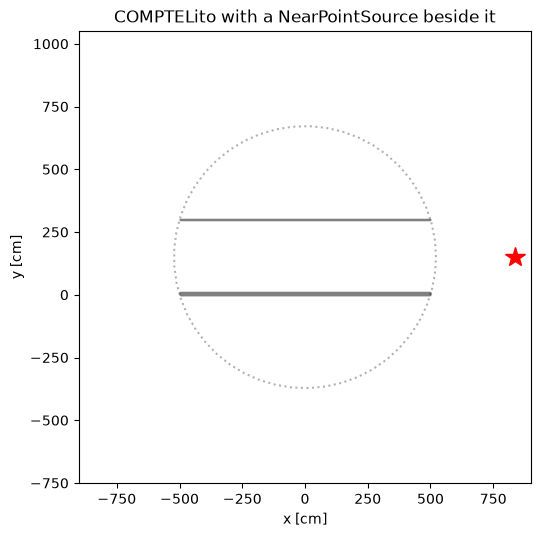

In [3]:
fig, ax = plt.subplots(figsize = (5.5, 5.5))
comptelito.plot(ax = ax, draw_surrounding_circle = True)

# NearFieldSource.plot marks the source with a red star at its actual position.
near_source_at(1.6).plot(ax, comptelito)

ax.set_title('COMPTELito with a NearPointSource beside it')
fig.tight_layout()

## 2. The acceptance is only half the story

`simulated_rate` says how many photons are *launched*. How many *trigger*
depends on the directions those photons fly in, and that is where placement
really bites. Same `rate`, two placements:

In [4]:
from gammaraytoys.sims import SimpleTraditionalReconstructor

reco = SimpleTraditionalReconstructor()

def trigger_stats(src, n = 3000, seed = 1):
    """Fraction of launched photons that interact at all, and that trigger."""
    np.random.seed(seed)
    n_interact = n_trigger = 0
    for _ in range(n):
        event = comptelito.simulate_event(src.random_photon(comptelito))
        if event.hits.nhits > 0:
            n_interact += 1
        if reco.reconstruct(event).triggered:
            n_trigger += 1
    return n_interact/n, n_trigger/n

print(f"{'placement':>16}  {'f':>8}  {'interact':>9}  {'trigger':>8}  {'triggers/s':>11}")
for label, ratio in [('at the centre', 0.0), ('10a outside', 10.0)]:
    src = near_source_at(ratio)
    f = (src.simulated_rate(comptelito)/(1000/u.s)).to_value(u.dimensionless_unscaled)
    f_int, f_trig = trigger_stats(src)
    print(f"{label:>16}  {f:8.4f}  {f_int*100:8.2f}%  {f_trig*100:7.2f}%  "
          f"{(1000*f*f_trig):11.3f}")

       placement         f   interact   trigger   triggers/s


   at the centre    1.0000     51.07%     1.30%       13.000


     10a outside    0.0319      5.13%     0.60%        0.191


Far apart, and the two effects compound: the acceptance is ~31x smaller for the
distant source, and the directions it *does* launch are worse ones,
trigger-wise, by a further factor of a few. A background component's *position*
matters as much as its activity.

It also changes what the *data* look like. Below, the measured energy spectrum
and the Compton Data Space for each placement, from the events that actually
triggered. The CDS convention is tutorial 02's: `Psi` (the scattered photon's
azimuth) on x, `Phi` (the Compton scatter angle) on y.

 at the centre:  150 triggers from 12367 launched


   10a outside:  150 triggers from 30852 launched


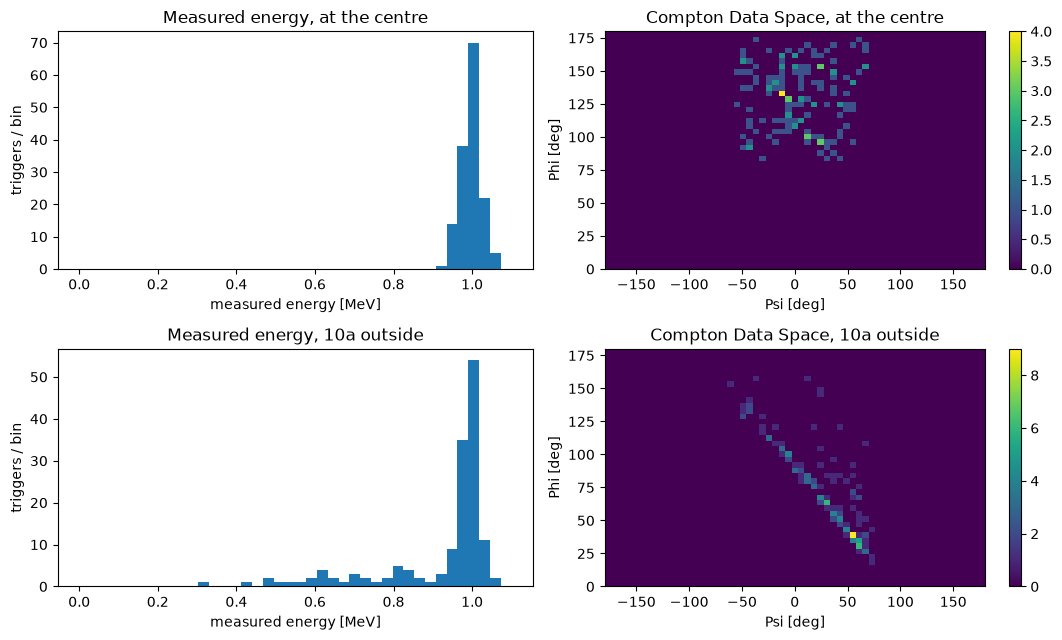

In [5]:
from histpy import Histogram, Axis

def triggered_events(src, n_target = 150, max_launches = 40000, seed = 3):
    """Collect `n_target` triggered reconstructions, or give up at `max_launches`.

    The cap keeps the runtime bounded: a distant near source triggers on well
    under 1% of what it launches, so an uncapped loop is unpredictable.
    """
    np.random.seed(seed)
    events = []
    launched = 0
    while len(events) < n_target and launched < max_launches:
        launched += 1
        reco_event = reco.reconstruct(comptelito.simulate_event(src.random_photon(comptelito)))
        if reco_event.triggered:
            events.append(reco_event)
    return events, launched

phi_axis = Axis(np.linspace(0, 180, 45)*u.deg, label = 'Phi')
psi_axis = Axis(np.linspace(-180, 180, 60)*u.deg, label = 'Psi')

fig, ax = plt.subplots(figsize = (11, 6.5), nrows = 2, ncols = 2)

for row, (label, ratio) in enumerate([('at the centre', 0.0), ('10a outside', 10.0)]):
    events, launched = triggered_events(near_source_at(ratio))
    print(f"{label:>14}: {len(events):4d} triggers from {launched} launched")

    energies = u.Quantity([e.energy for e in events]).to_value(u.MeV)
    ax[row][0].hist(energies, bins = 40, range = (0, 1.1), color = 'tab:blue')
    ax[row][0].set_xlabel('measured energy [MeV]')
    ax[row][0].set_ylabel('triggers / bin')
    ax[row][0].set_title(f'Measured energy, {label}')

    h_cds = Histogram([psi_axis, phi_axis])
    h_cds.fill(u.Quantity([e.psi for e in events]).to(u.deg),
               u.Quantity([e.phi for e in events]).to(u.deg),
               warn_overflow = False)
    h_cds.plot(ax[row][1])
    ax[row][1].set_title(f'Compton Data Space, {label}')

fig.tight_layout()

The near source at the centre fills the CDS broadly -- it emits into every
direction from inside the instrument, so there is no single incoming direction
for the events to organise themselves around. The distant one is confined to a
narrow wedge of arrival directions, and its CDS is correspondingly tighter.
Neither shows the clean `Psi`-`Phi` locus that a far-field point source traces
out in tutorial 02, which is the point: this is what background looks like.

## 3. The blind wedge, honestly

The plan's Section 8 trap 5 warns that near-field sources have a blind wedge,
and it is worth showing rather than hiding. The detector's layers are
**infinitesimal planes** of finite length -- an approximation the tutorials
make deliberately, for simplicity. A photon that crosses a layer's *plane*
beyond `|x| > layer_length/2` misses the layer entirely.

So a source between two layers, emitting nearly horizontally, can travel out of
the detector without ever crossing a layer. The blind half-angle is

    arctan(dy / run)

where `dy` is the vertical gap to the nearest layer plane and `run` is the
horizontal distance left before the layer's edge. **It depends on where the
source sits**, which is why there is no single number for it.

In [6]:
from gammaraytoys.sims import Photon

edge = comptelito.right_bound.to_value(u.cm)

def interaction_fraction(x_cm, tilt_deg, n = 400, seed = 2):
    """Fraction of photons that interact, emitted `tilt_deg` from horizontal.

    Only the two directions heading toward the *near* edge are used. Emitting
    the other way gives the photon the full width of the stack to cross a
    layer in, which has nothing to do with the wedge being measured and would
    simply dilute it.
    """
    np.random.seed(seed)
    position = Cartesian2D(x_cm*u.cm, 5.5*u.cm)   # 0.5 cm above the layer at y = 5 cm
    hits = 0
    for _ in range(n):
        direction = np.random.choice([tilt_deg, -tilt_deg])*u.deg
        event = comptelito.simulate_event(
            Photon(position = position, direction = direction,
                   energy = 1*u.MeV, chirality = None))
        if event.hits.nhits > 0:
            hits += 1
    return hits/n

for x_cm, label in [(0.0, 'stack centre'), (495.0, 'near the edge')]:
    run = edge - abs(x_cm)
    cutoff = np.degrees(np.arctan(0.5/run))
    print(f"\n  source at x = {x_cm:.0f} cm ({label}): {run:.0f} cm of run left")
    print(f"  predicted blind half-angle = arctan(0.5/{run:.0f}) = {cutoff:.4f} deg")
    for tilt in [10*cutoff, 2*cutoff, cutoff, 0.5*cutoff]:
        print(f"      {tilt:9.4f} deg from horizontal -> interacts "
              f"{interaction_fraction(x_cm, tilt)*100:5.1f}%")


  source at x = 0 cm (stack centre): 500 cm of run left
  predicted blind half-angle = arctan(0.5/500) = 0.0573 deg


         0.5730 deg from horizontal -> interacts 100.0%


         0.1146 deg from horizontal -> interacts  99.8%


         0.0573 deg from horizontal -> interacts  46.5%
         0.0286 deg from horizontal -> interacts   0.0%

  source at x = 495 cm (near the edge): 5 cm of run left
  predicted blind half-angle = arctan(0.5/5) = 5.7106 deg


        57.1059 deg from horizontal -> interacts  79.2%


        11.4212 deg from horizontal -> interacts  66.5%
         5.7106 deg from horizontal -> interacts   0.0%


         2.8553 deg from horizontal -> interacts   0.0%


The cliff lands exactly where the geometry says it should, in both cases -- and
the two cases differ by a factor of a hundred in angle. At the centre of a 10 m
stack the blind wedge is a knife-edge of a few hundredths of a degree; a source
tucked 5 cm from the edge is blind over several degrees.

This shows up as **reduced efficiency, not as a wrong normalization**: those
photons were still launched, still counted in `simulated_rate`, and simply did
not interact. That is the correct behaviour under the infinitesimal-plane
approximation, and it is why the tutorials say what they say about it.

## 4. `ExtendedSource`: a von Mises blob on the sky

Back to the far field. `ExtendedSource` puts a **von Mises** distribution on
the sky, centred on `sky_angle` with a spread `width`. Von Mises rather than a
Gaussian because it wraps by construction -- no truncation, no double-counting
across 360 deg, exactly normalized on the circle.

Internally `kappa = 1/width**2` (with `width` in radians), which makes `width`
the distribution's standard deviation **in the small-width limit**. It is a
good approximation to about 10 deg and degrades after that, which is worth
knowing before reading too much into a very wide source's `width`.

`flux` is the total integrated over the **whole sky**, exactly as for
`IsotropicSource` -- so the number of photons launched does not depend on
`width` at all.

In [7]:
from gammaraytoys.sims import (ExtendedSource, IsotropicSource, PointSource,
                               Earth, SpacecraftInterval)
from gammaraytoys.coordinates import sky_angle_to_offaxis

earth = Earth()
sky_angle = 40*u.deg
flux = 1e-3/u.cm/u.s

# A pose far from the Earth's shadow, so nothing below is occulted.
pose = SpacecraftInterval(start_time = 0*u.s, stop_time = 1*u.s, livetime = 1*u.s,
                          attitude = 90*u.deg, orbit_angle = 90*u.deg,
                          orbit_radius = 6771*u.km)

print("simulated_rate is independent of width (flux is a whole-sky total):")
for width in [0.1, 1, 10, 90]*u.deg:
    src = ExtendedSource(sky_angle = sky_angle, width = width,
                         spectrum = MonoenergeticSpectrum(1*u.MeV), flux = flux)
    print(f"    width = {width:6.1f}  ->  {src.simulated_rate(comptelito).to(1/u.s):.4f}")

isotropic = IsotropicSource(spectrum = MonoenergeticSpectrum(1*u.MeV), flux = flux)
print(f"    IsotropicSource, same flux -> {isotropic.simulated_rate(comptelito).to(1/u.s):.4f}")

simulated_rate is independent of width (flux is a whole-sky total):
    width =    0.1 deg  ->  1.0440 1 / s
    width =    1.0 deg  ->  1.0440 1 / s
    width =   10.0 deg  ->  1.0440 1 / s
    width =   90.0 deg  ->  1.0440 1 / s
    IsotropicSource, same flux -> 1.0440 1 / s


  width =    5.0 deg: realised spread = 5.05 deg


  width =   20.0 deg: realised spread = 20.55 deg


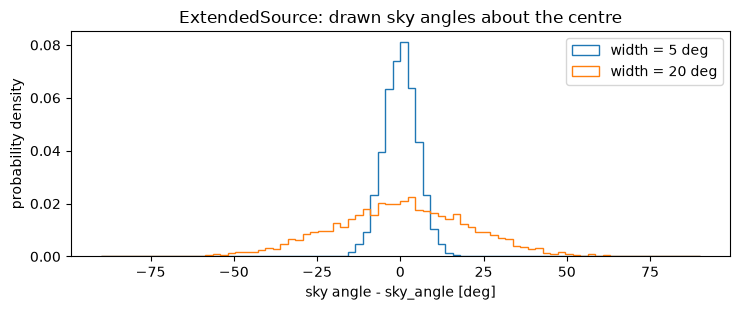

In [8]:
def drawn_sky_angles(src, n, seed = 3):
    """Sky angles of `n` photons drawn at `pose`, inverting the frame transform.

    `random_photon` hands back a detector-frame direction, and the conventions
    chain as direction = 270 deg - Nu and Nu = A - lambda, so
    lambda = A - (270 deg - direction).
    """
    np.random.seed(seed)
    attitude = pose.attitude.to_value(u.deg)
    out = []
    while len(out) < n:
        photon = src.random_photon(comptelito, pose, earth)
        if photon is not None:
            out.append(attitude - (270 - photon.direction.to_value(u.deg)))
    # Wrap into a residual about the source centre, for plotting.
    residual = np.angle(np.exp(1j*np.radians(np.array(out) - sky_angle.to_value(u.deg))))
    return np.degrees(residual)

fig, ax = plt.subplots(figsize = (7.5, 3.2))

for width, colour in [(5*u.deg, 'tab:blue'), (20*u.deg, 'tab:orange')]:
    src = ExtendedSource(sky_angle = sky_angle, width = width,
                         spectrum = MonoenergeticSpectrum(1*u.MeV), flux = flux)
    residual = drawn_sky_angles(src, 4000)
    ax.hist(residual, bins = 80, range = (-90, 90), histtype = 'step',
            density = True, color = colour, label = f'width = {width:.0f}')
    print(f"  width = {width:6.1f}: realised spread = "
          f"{np.degrees(np.sqrt(-2*np.log(abs(np.mean(np.exp(1j*np.radians(residual))))))):.2f} deg")

ax.set_xlabel('sky angle - sky_angle [deg]')
ax.set_ylabel('probability density')
ax.set_title('ExtendedSource: drawn sky angles about the centre')
ax.legend()
fig.tight_layout()

The realised spread tracks `width` closely at 5 deg and starts to drift at
20 deg, exactly as the `kappa = 1/width**2` small-angle identification predicts.

### The two limits

The cheapest check that the normalization convention is right: a very narrow
`ExtendedSource` must behave like a `PointSource` at the same flux and angle,
and a very wide one like an `IsotropicSource`. Both limits are about the
*distribution*; the rate, as shown above, already matches by construction.

In [9]:
narrow = ExtendedSource(sky_angle = sky_angle, width = 0.01*u.deg,
                        spectrum = MonoenergeticSpectrum(1*u.MeV), flux = flux)
residual = drawn_sky_angles(narrow, 2000, seed = 4)
print(f"narrow limit (width = 0.01 deg): max |sky angle - sky_angle| = "
      f"{np.abs(residual).max():.4f} deg  -- a point source for all practical purposes")

# 'Wide' has to be genuinely wide: kappa = 1/width**2 means width = 180 deg is
# still kappa = 0.10, which is visibly peaked. 720 deg gives kappa = 0.006.
wide = ExtendedSource(sky_angle = sky_angle, width = 720*u.deg,
                      spectrum = MonoenergeticSpectrum(1*u.MeV), flux = flux)

# Compare against IsotropicSource *at the same pose*, with a two-sample test,
# rather than against a flat distribution. At this altitude the Earth blocks a
# ~140 deg wedge of sky, so neither source's drawn angles are uniform -- but
# they should be identically non-uniform, which is the actual claim.
from scipy import stats

wide_angles = drawn_sky_angles(wide, 6000, seed = 5)
iso_angles = drawn_sky_angles(isotropic, 6000, seed = 6)

p_value = stats.ks_2samp(wide_angles, iso_angles).pvalue
print(f"wide limit (width = 720 deg) vs IsotropicSource at the same pose:")
print(f"    two-sample KS p = {p_value:.3f}  -- the two are indistinguishable")

narrow limit (width = 0.01 deg): max |sky angle - sky_angle| = 0.0356 deg  -- a point source for all practical purposes


wide limit (width = 720 deg) vs IsotropicSource at the same pose:
    two-sample KS p = 0.130  -- the two are indistinguishable


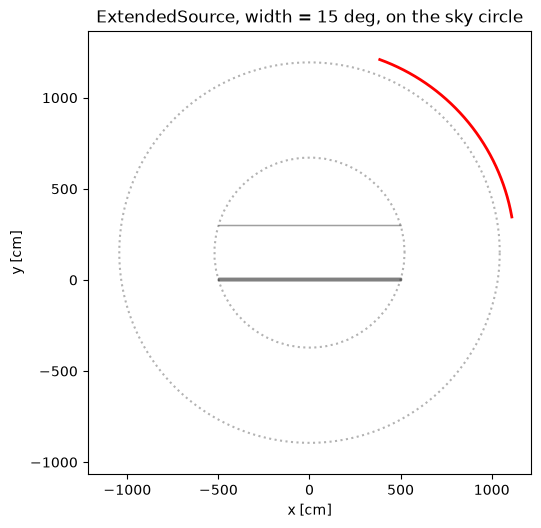

In [10]:
fig, ax = plt.subplots(figsize = (5.5, 5.5))
comptelito.plot(ax = ax, draw_surrounding_circle = True)

source = ExtendedSource(sky_angle = sky_angle, width = 15*u.deg,
                        spectrum = MonoenergeticSpectrum(1*u.MeV), flux = flux)

# plot() needs an attitude to convert the inertial sky_angle into a
# detector-frame direction, which it takes from the last pose it was drawn at.
source.random_photon(comptelito, pose, earth)
source.plot(ax, comptelito)

ax.set_title(f'ExtendedSource, width = {source.width:.0f}, on the sky circle')
fig.tight_layout()

The arc spans `4 x width` (`+/- 2 sigma`) just outside the dotted sky circle,
centred on the source's **own** direction -- not on wherever the last photon
happened to be drawn.

## 5. Both at once

`Simulator` mixes the two families by summing `simulated_rate()`, so a
flux-normalized sky source and a rate-normalized instrumental background can
share one run. The near source is placed inside the instrument, where its
acceptance is 1.

In [11]:
from gammaraytoys.sims import Simulator

background = NearPointSource(position = Cartesian2D(centre.x, centre.y),
                             spectrum = MonoenergeticSpectrum(0.5*u.MeV),
                             rate = 40/u.s)
sky = PointSource(offaxis_angle = 0*u.deg,
                  spectrum = MonoenergeticSpectrum(1*u.MeV),
                  flux = 4/u.cm/u.s)

simulator = Simulator(comptelito, [sky, background], reco)

# .to(1/u.s) because flux * throwing_plane_size lands in 1/cm/s * m, which is
# a rate but does not print like one.
print(f"sky source     simulated_rate = {sky.simulated_rate(comptelito).to(1/u.s):.2f}")
print(f"background     simulated_rate = {background.simulated_rate(comptelito).to(1/u.s):.2f}")
print(f"total                         = {simulator.total_simulated_rate.to(1/u.s):.2f}")

sky source     simulated_rate = 4176.12 1 / s
background     simulated_rate = 40.00 1 / s
total                         = 4216.12 1 / s


Where they sit, both on one pair of axes. The far-field source is a *direction*
and so is marked on the dotted sky circle; the near-field one is a *position*
and is marked where it actually is, at the centre of the layer stack. The same
two `plot` methods used separately in Sections 1 and 4, called on the same axes.

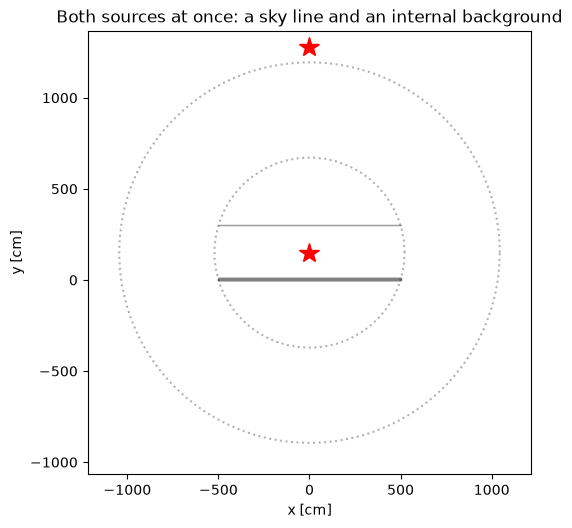

In [12]:
fig, ax = plt.subplots(figsize = (5.5, 5.5))
comptelito.plot(ax = ax, draw_surrounding_circle = True)

sky.plot(ax, comptelito)          # sky circle + star, at Nu = 0 deg
background.plot(ax, comptelito)   # red star at the detector-frame position

ax.set_title('Both sources at once: a sky line and an internal background')
fig.tight_layout()

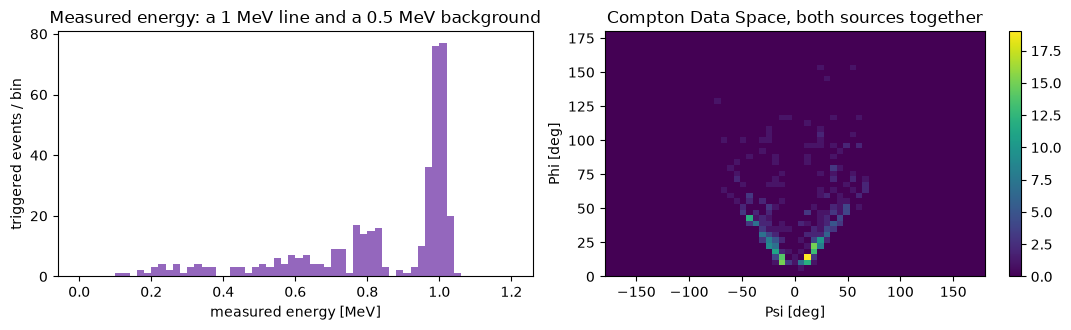

In [13]:
np.random.seed(7)
events = [event for _, event in simulator.run_events(ntrig = 400, progress = False)
          if event.triggered]

fig, ax = plt.subplots(figsize = (11, 3.4), ncols = 2)

ax[0].hist(u.Quantity([e.energy for e in events]).to_value(u.MeV),
           bins = 60, range = (0, 1.2), color = 'tab:purple')
ax[0].set_xlabel('measured energy [MeV]')
ax[0].set_ylabel('triggered events / bin')
ax[0].set_title('Measured energy: a 1 MeV line and a 0.5 MeV background')

h_cds = Histogram([psi_axis, phi_axis])
h_cds.fill(u.Quantity([e.psi for e in events]).to(u.deg),
           u.Quantity([e.phi for e in events]).to(u.deg),
           warn_overflow = False)
h_cds.plot(ax[1])
ax[1].set_title('Compton Data Space, both sources together')

fig.tight_layout()

Both components show up, each normalized in its own currency -- a flux for the
one at infinity, a rate for the one bolted to the spacecraft -- and
`simulated_rate()` is what lets a single run hold both.

In the energy spectrum they separate cleanly, because the two lines were chosen
an octave apart. In the CDS they overlap: the on-axis sky source contributes
the structured locus tutorial 02 describes, sitting on top of the broad,
unstructured background the internal source produces. Separating those two
without the luxury of distinct line energies is what the later tutorials'
likelihood machinery is for.